<a href="https://colab.research.google.com/github/mserhat1/NMA_Project/blob/main/testing_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IF YOU WANT TO TEST, GO TO THE END OF THE NOTEBOOK WITH THE HEADLINE "TRAINING AND TEST"

In [ ]:
!git clone https://github.com/mserhat1/NMA_Project.git
import sys
sys.path.append('/content/NMA_Project')

In [ ]:
%cd NMA_Project
!pip install -r requirements.txt

In [ ]:
from functions.data import get_datafile

# sbj 6 has visual cortex electrodes

sbj = 10
session = 3

nwbfile = get_datafile(sbj=sbj, session=session)

Extract spatial data

In [ ]:
from functions.data import extract_spatial_data

spatial_data = extract_spatial_data(nwbfile)

Extract neural data

In [ ]:
from functions.data import extract_neural_data

# specify parameters
channel = 'all'
#train_window = (0, 43200)
#test_window = (43200, 86400)

ecog_data = extract_neural_data(nwbfile, channel=channel, time_window=(55000, 56500))

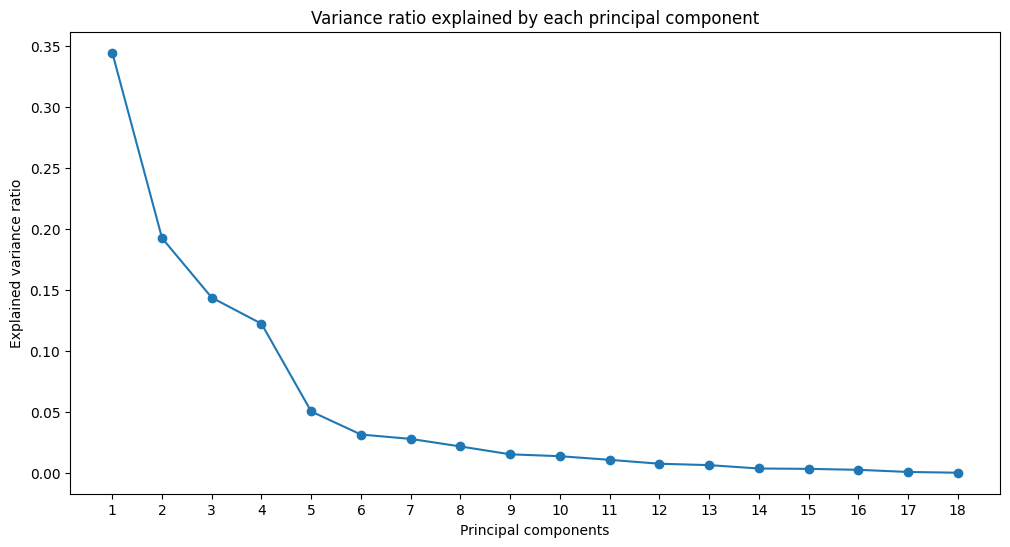

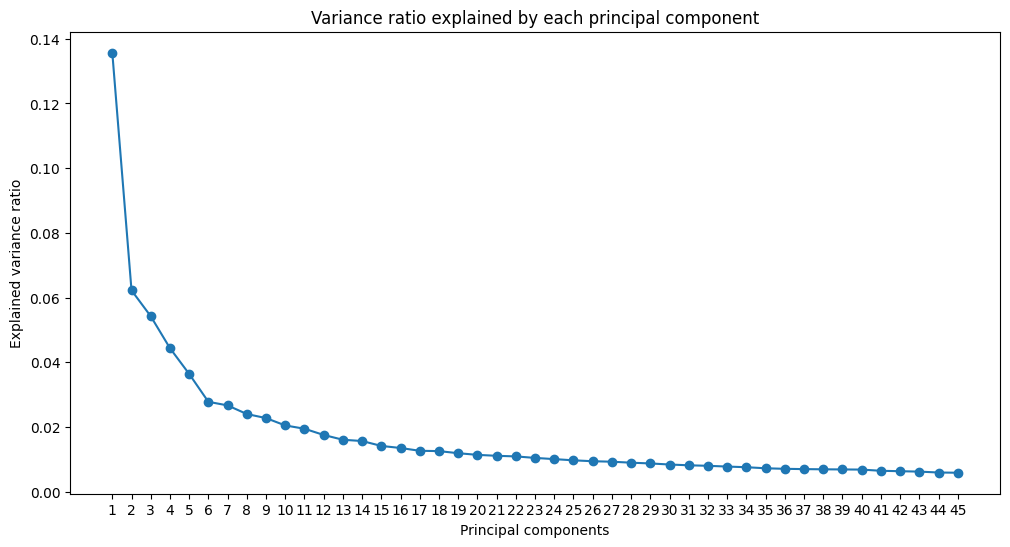

In [ ]:
from functions.analysis import keypoints_pca, ecog_pca

spatial_pca = keypoints_pca(spatial_data, interp_reference=ecog_data['signal'], time_window=(55000, 56500), plot=True)
neural_pca = ecog_pca(ecog_data, time_window=(55000, 56500), n_components=0.80, plot=True)

In [ ]:
# Seems like 4 PC's is a good choice in this case.
chosen_pcs = 4

kp_data = spatial_pca['kp_data']
pcs = spatial_pca['components'] # (n_components, n_features)
top_pcs = pcs[:chosen_pcs, :]

print(top_pcs.shape, kp_data.shape)
projected_spatial = kp_data @ top_pcs.T

print(projected_spatial.shape) # (n_samples, n_components)

(4, 18) (750000, 18)
(750000, 4)


In [ ]:
chosen_pcs = 12
neural_data = neural_pca['kp_data']
pcs = neural_pca['components'] # (n_components, n_features)
top_pcs = pcs[:chosen_pcs, :]

print(top_pcs.shape, neural_data.shape)
projected_neural = neural_data @ top_pcs.T

print(projected_neural.shape) # (n_samples, n_components)

(12, 126) (750000, 126)
(750000, 12)


In [ ]:
from functions.model import RRR

A, C = RRR(projected_spatial, projected_neural)

In [ ]:
print(A.shape, C.shape)

(4, 4) (12, 4)


TRAINING AND TEST

In [18]:
# you can adjust windows etc., using the entire 86400 sample window is not advisable, takes too long.

from functions.data import extract_spatial_data
from functions.data import extract_neural_data
from functions.analysis import keypoints_pca, ecog_pca, project_onto_pcs

train_window = (40000, 40030)
test_window = (40030, 40060)
channel='all'

spatial_data = extract_spatial_data(nwbfile)
ecog_train = extract_neural_data(nwbfile, channel=channel, time_window=train_window)
ecog_test = extract_neural_data(nwbfile, channel=channel, time_window=test_window)

spatial_pca_train = keypoints_pca(spatial_data, interp_reference=ecog_train['signal'], time_window=train_window, plot=False)
neural_pca_train = ecog_pca(ecog_train, time_window=train_window, n_components=0.80, plot=False)

spatial_pca_test = keypoints_pca(spatial_data, interp_reference=ecog_test['signal'], time_window=test_window, plot=False)
neural_pca_test = ecog_pca(ecog_test, time_window=test_window, n_components=0.80, plot=False)

proj_spatial_train = project_onto_pcs(spatial_pca_train, n_pcs=4)
proj_neural_train = project_onto_pcs(neural_pca_train, n_pcs=12)

proj_spatial_test = project_onto_pcs(spatial_pca_test, n_pcs=4)
proj_neural_test = project_onto_pcs(neural_pca_test, n_pcs=12)

In [19]:
from functions.model import RRR

A, C = RRR(proj_spatial_train, proj_neural_train)

In [20]:
estimated_neural_test = proj_spatial_test @ A @ C.T

In [21]:
print(A)

[[-0.00973601  0.01141041  0.01193683  0.01747382]
 [ 0.06714462 -0.03665314  0.05940516 -0.00706623]
 [-0.20567341  0.0294639   0.04088537 -0.01906216]
 [-0.12350908 -0.14005125 -0.01932389  0.01769999]]


In [22]:
print(estimated_neural_test)

[[ 0.33538752  0.16173348  0.09775974 ... -0.10849546  0.10972208
   0.00731074]
 [ 0.33490437  0.16145329  0.09778249 ... -0.10822528  0.10956611
   0.00723595]
 [ 0.33442122  0.16117311  0.09780524 ... -0.1079551   0.10941014
   0.00716116]
 ...
 [-0.09395536 -0.10136232 -0.29430786 ...  0.07365048 -0.01338508
  -0.05459267]
 [-0.09384614 -0.10114581 -0.29374184 ...  0.07342943 -0.0134057
  -0.05442295]
 [-0.09373692 -0.1009293  -0.29317582 ...  0.07320838 -0.01342632
  -0.05425322]]


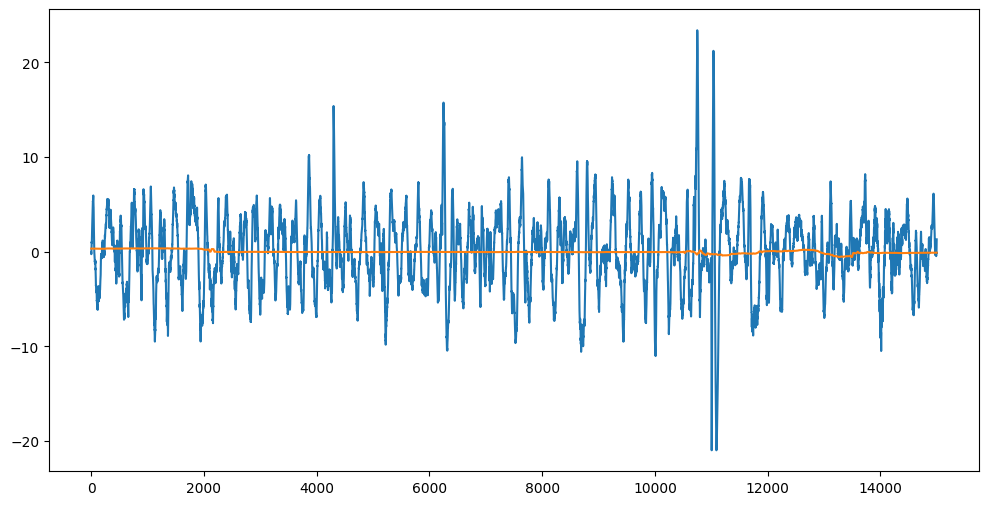

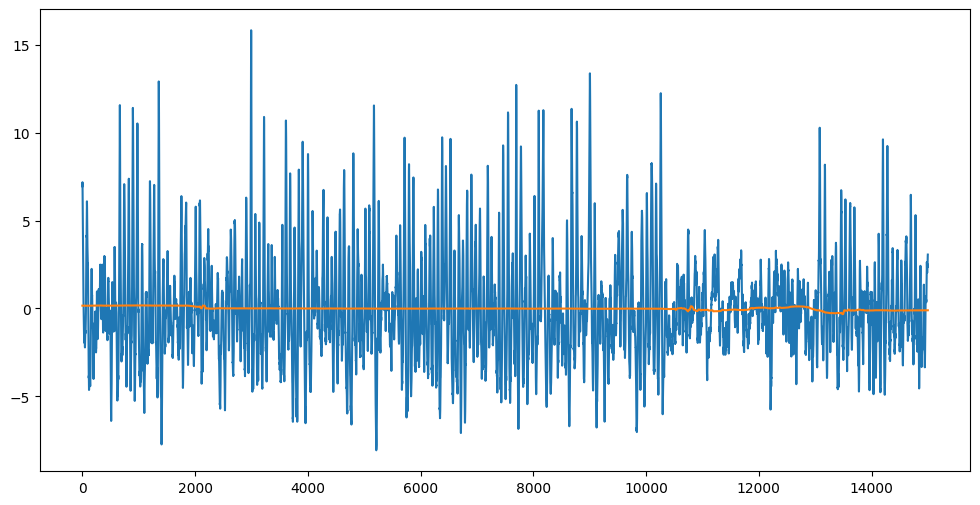

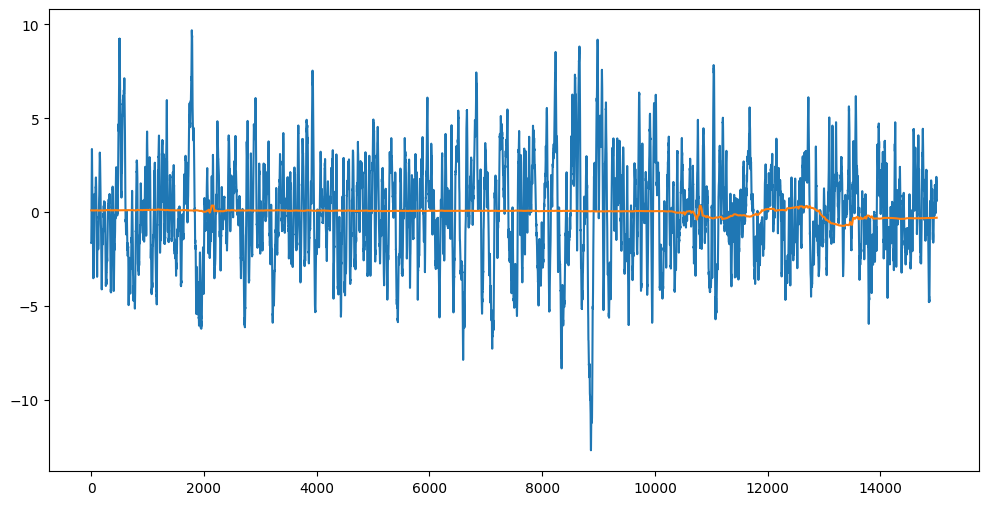

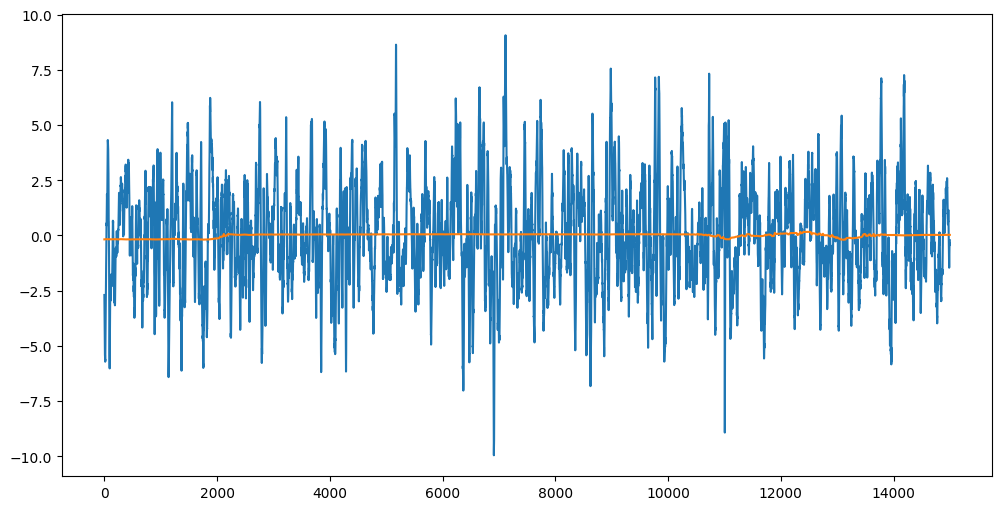

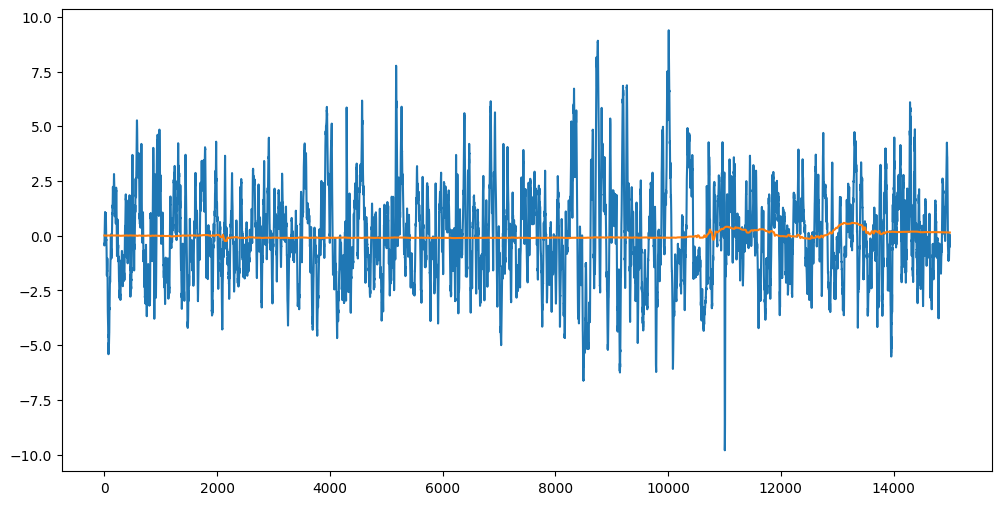

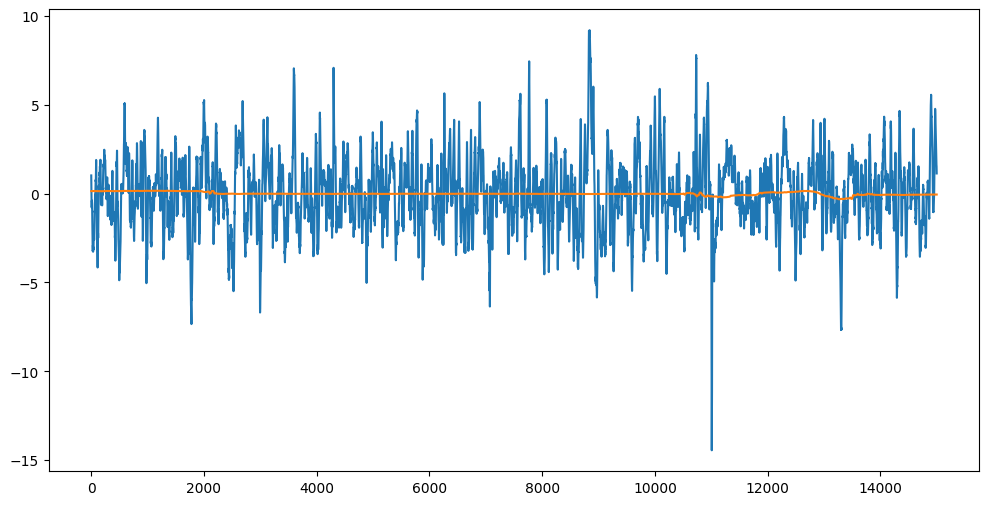

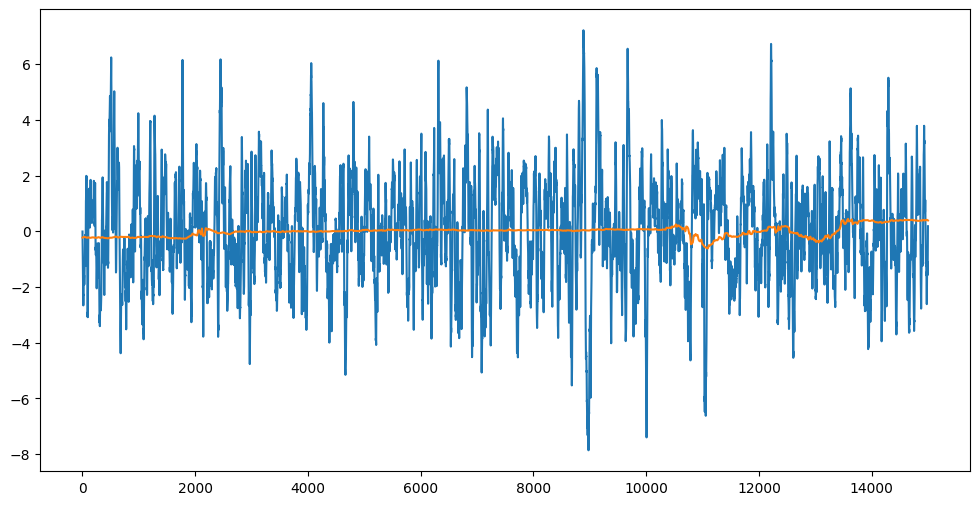

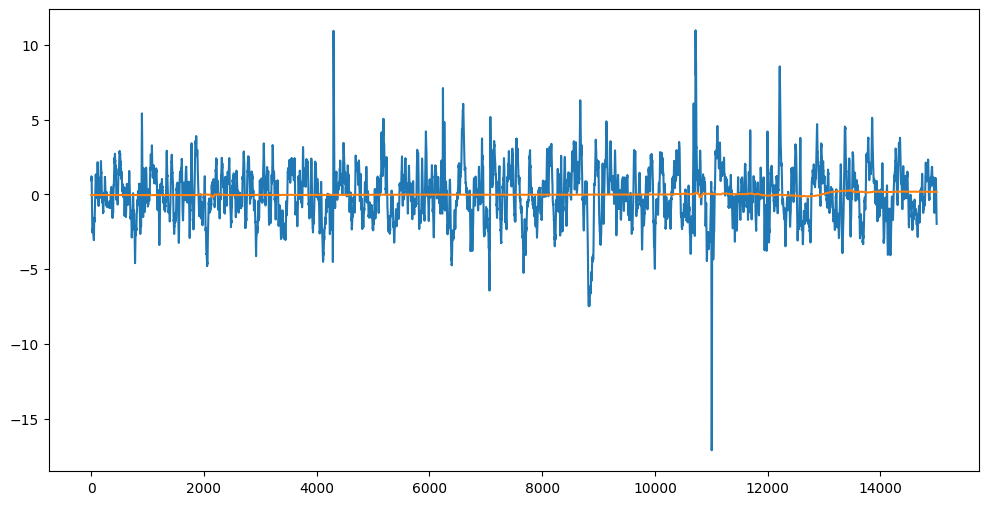

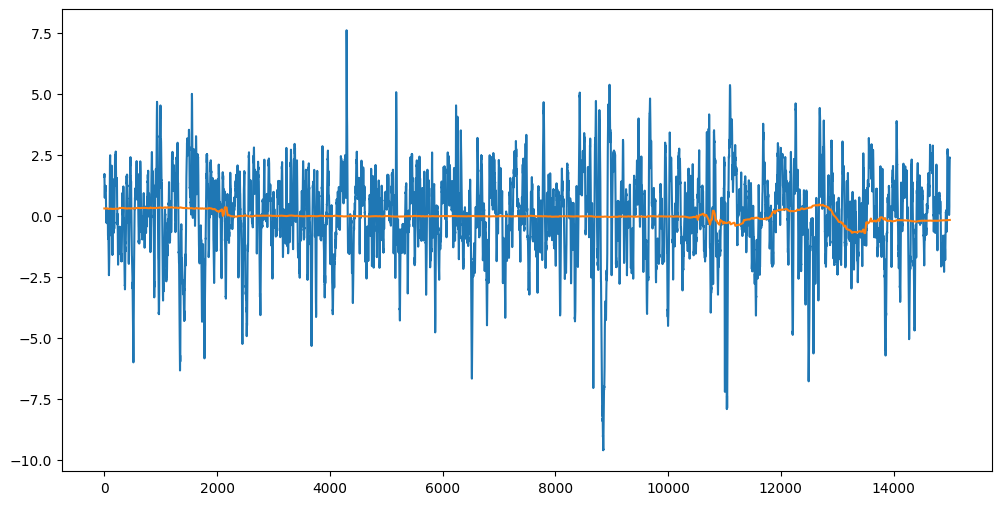

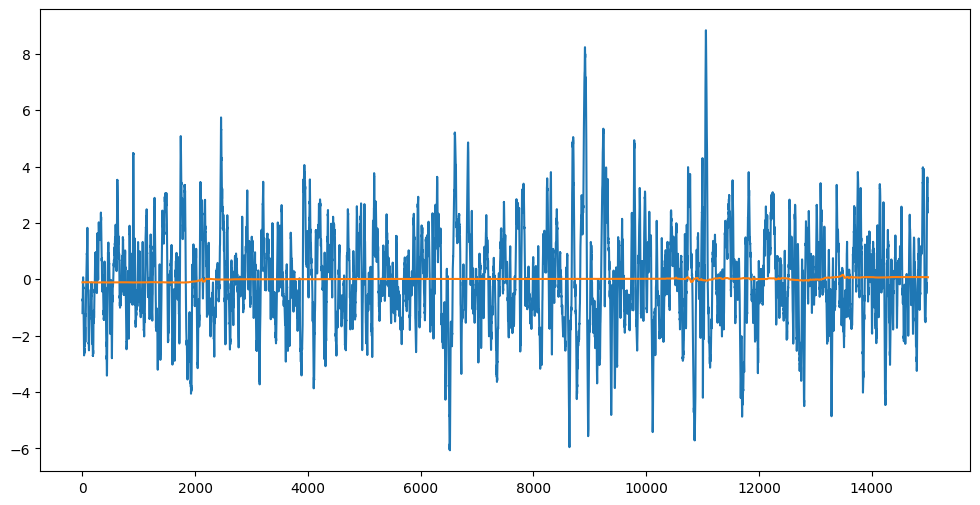

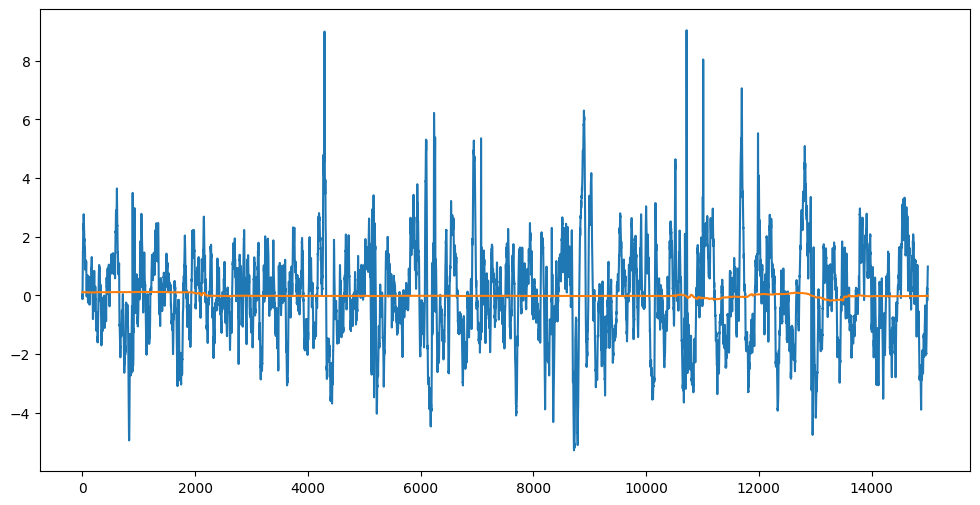

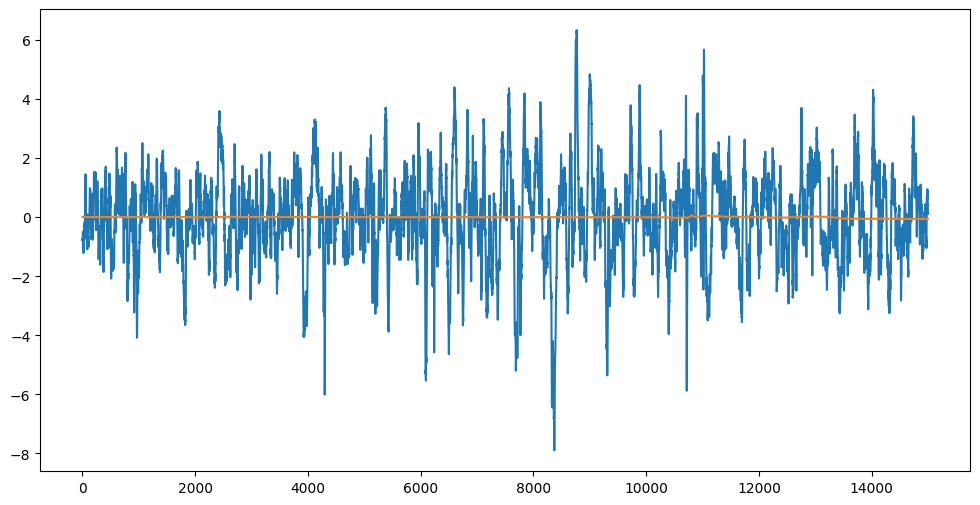

In [23]:
import numpy as np
import matplotlib.pyplot as plt

for i in range(proj_neural_test.shape[1]):
  plt.figure(figsize=(12, 6))
  plt.plot(proj_neural_test[:, i], label='True')
  plt.plot(estimated_neural_test[:, i], label='Estimated')
